# Lesson 09 - The Perceptron and its Limits

**Phase 1: The First Networks** &nbsp;|&nbsp; Deep Learning From Scratch

> Build the 1958 neuron and hit the XOR wall that froze the field.

Runs top to bottom on Kaggle, Colab or locally. Nothing to download.

---

## 1. Plan

**What we build today**

Frank Rosenblatt's perceptron, exactly as published in 1958: a step function,
a learning rule with no calculus in it at all, and a convergence guarantee.
We train it on AND and OR, watch it succeed, then train it on XOR and watch
it **fail forever** — cycling at four errors per epoch, with no error raised
and no sign of distress. Then we prove algebraically that no setting of the
weights could ever have worked.

**Why it exists**

Two reasons, and again the second matters more.

1. It is the historical origin of the whole field, and the learning rule is
   beautiful: no derivatives, four lines of code, and a theorem saying it
   *must* converge when a solution exists.
2. **It shows you exactly what a single layer cannot do.** A linear model —
   Lesson 06's, Lesson 08's, and this one — carves the input space with one
   straight boundary. Some problems are not shaped like that. Hidden layers
   are not a clever trick someone thought of; they are the *forced* response
   to a proof of impossibility.

**What breaks without it**

If you skip this, the multi-layer network in Lesson 10 looks arbitrary —
"stack more layers, it works better." After today it looks inevitable: you
will have watched a single layer be *provably* incapable, and then seen two
units fix it by carving two lines instead of one.

There is also a concrete lesson in failure modes. The perceptron on
non-separable data does not crash, warn, or slow down. It runs its full
budget and returns confident-looking weights that are simply the last ones
it happened to hold. **Silent non-convergence** is the failure mode, and
recognising it is a transferable skill.

## 2. From scratch: the maths

### 2.1 The model

$$\hat{y} = \text{step}(z), \qquad z = \mathbf{w}\cdot\mathbf{x} + b,
  \qquad \text{step}(z) = \begin{cases} 1 & z > 0 \\ 0 & z \le 0\end{cases}$$

Identical to Lesson 08 except the sigmoid is replaced by a hard threshold.
The output is a *decision*, not a probability — there is no notion of
confidence, and no way to be "slightly wrong".

### 2.2 The learning rule

For each sample in turn:

$$\mathbf{w} \leftarrow \mathbf{w} + \eta\,(y - \hat{y})\,\mathbf{x},
  \qquad b \leftarrow b + \eta\,(y - \hat{y})$$

Since both $y$ and $\hat{y}$ are 0 or 1, the factor $(y - \hat{y})$ takes
exactly three values, and reading them off tells you the entire algorithm:

| $y$ | $\hat{y}$ | $y - \hat{y}$ | what happens |
|---|---|---|---|
| 0 | 0 | $0$ | correct — **nothing changes** |
| 1 | 1 | $0$ | correct — **nothing changes** |
| 1 | 0 | $+1$ | missed a positive: **add $\mathbf{x}$**, pushing $z$ up |
| 0 | 1 | $-1$ | false positive: **subtract $\mathbf{x}$**, pushing $z$ down |

Why does adding $\mathbf{x}$ help? Because the new logit for that same input
becomes

$$(\mathbf{w} + \eta\mathbf{x})\cdot\mathbf{x} + (b + \eta)
  = z + \eta\left(\lVert\mathbf{x}\rVert^2 + 1\right)$$

and $\lVert\mathbf{x}\rVert^2 + 1 > 0$ always. **The update is guaranteed to
move that sample's logit in the right direction** — not necessarily far
enough to fix it in one go, and possibly at the expense of other samples,
but never the wrong way.

### 2.3 This is not gradient descent

It cannot be. The step function has derivative **zero everywhere** it is
defined, and is undefined at $z = 0$:

$$\frac{d}{dz}\text{step}(z) = 0 \quad \text{for all } z \neq 0$$

So $\partial L/\partial w = \frac{\partial L}{\partial \hat{y}}\cdot 0 = 0$.
Every gradient is zero, every gradient step does nothing, and gradient
descent is not merely inefficient here — it is *inapplicable*. Rosenblatt's
rule sidesteps calculus entirely and manipulates the weights directly.

This is precisely why Lesson 08's sigmoid mattered. **Replacing the step
with a smooth squashing function is what made calculus — and therefore
backpropagation — possible at all.** The sigmoid is a differentiable step.

### 2.4 The convergence theorem

Rosenblatt proved: *if the data is linearly separable, the perceptron rule
reaches zero errors in a finite number of updates* — bounded by
$(R/\gamma)^2$, where $R$ is the largest input norm and $\gamma$ the margin
of the best separator. No learning-rate tuning, no local minima.

The theorem is silent about non-separable data, and that silence is the
whole story of the next thirty years.

### 2.5 XOR is impossible — a proof, not an observation

XOR: output 1 when exactly one input is 1.

| $x_1$ | $x_2$ | $y$ |
|---|---|---|
| 0 | 0 | 0 |
| 0 | 1 | 1 |
| 1 | 0 | 1 |
| 1 | 1 | 0 |

Suppose some $w_1, w_2, b$ computed it. Writing out what each row demands:

$$\begin{aligned}
(0,0)\rightarrow 0 &: \quad b \le 0 &(1)\\
(0,1)\rightarrow 1 &: \quad w_2 + b > 0 &(2)\\
(1,0)\rightarrow 1 &: \quad w_1 + b > 0 &(3)\\
(1,1)\rightarrow 0 &: \quad w_1 + w_2 + b \le 0 &(4)
\end{aligned}$$

Add (2) and (3):

$$w_1 + w_2 + 2b > 0$$

Rearrange (4):

$$w_1 + w_2 \le -b$$

Substitute the second into the first:

$$0 < (w_1 + w_2) + 2b \le -b + 2b = b$$

so $b > 0$ — contradicting (1), which said $b \le 0$. **No such weights
exist.** Not "are hard to find": do not exist.

The geometric reading: the two positive points $(0,1)$ and $(1,0)$ lie on
the diagonal between the two negative points $(0,0)$ and $(1,1)$. The
diagonals of a square cross. A single straight line cannot separate two
crossing diagonals, and one straight line is all a single layer has.

### 2.6 The fix, visible in advance

$$\text{XOR}(x_1,x_2) = \text{OR}(x_1,x_2) \;\wedge\; \neg\,\text{AND}(x_1,x_2)$$

"at least one, but not both." OR and AND are each linearly separable, so two
perceptrons can compute them — and a third can combine the results, because
in the new $(\text{OR}, \text{AND})$ coordinate system the problem *has*
become linearly separable.

That intermediate layer is a **hidden layer**, and this is what it is for:
not "more capacity" in the abstract, but re-representing the input in
coordinates where a straight line finally suffices. Lesson 10 builds it
properly; today we place the weights by hand so you can see the mechanism
with nothing hidden.

## 3. Numerical: worked by hand

Training AND from $\mathbf{w} = [0,0]$, $b = 0$, with $\eta = 1$, presenting
samples in the order $(0,0), (0,1), (1,0), (1,1)$.

Remember $\text{step}(0) = 0$, since the rule is $z > 0$, strictly.

### Epoch 1

| sample | $z = \mathbf{w}\cdot\mathbf{x}+b$ | $\hat{y}$ | $y$ | $y-\hat{y}$ | new $\mathbf{w}$, $b$ |
|---|---|---|---|---|---|
| $(0,0)$ | $0$ | 0 | 0 | 0 | unchanged |
| $(0,1)$ | $0$ | 0 | 0 | 0 | unchanged |
| $(1,0)$ | $0$ | 0 | 0 | 0 | unchanged |
| $(1,1)$ | $0$ | 0 | **1** | $+1$ | $\mathbf{w}=[1,1]$, $b=1$ |

One error. The only update came from the single positive example, and it
added $\mathbf{x} = [1,1]$ to the weights exactly as the rule says.

### Epoch 2 — starting from $\mathbf{w} = [1,1]$, $b = 1$

| sample | $z$ | $\hat{y}$ | $y$ | $y-\hat{y}$ | new $\mathbf{w}$, $b$ |
|---|---|---|---|---|---|
| $(0,0)$ | $0+0+1 = 1$ | 1 | 0 | $-1$ | $\mathbf{w}=[1,1]$, $b=0$ |
| $(0,1)$ | $0+1+0 = 1$ | 1 | 0 | $-1$ | $\mathbf{w}=[1,0]$, $b=-1$ |
| $(1,0)$ | $1+0-1 = 0$ | 0 | 0 | $0$ | unchanged |
| $(1,1)$ | $1+0-1 = 0$ | 0 | **1** | $+1$ | $\mathbf{w}=[2,1]$, $b=0$ |

Three errors — *more* than epoch 1. The perceptron does not descend
monotonically; it lurches. The theorem promises it terminates, not that it
improves every step.

Note the first update in epoch 2: $\mathbf{x} = [0,0]$, so the weights
cannot change at all and **only the bias moves**. A zero input carries no
information about which way to rotate the boundary, only about where to put
it.

### The end state

Continuing, AND converges after **6 epochs** to $\mathbf{w} = [2,1]$,
$b = -2$. Check it: $(1,1)$ gives $2+1-2 = 1 > 0$ → 1. $(1,0)$ gives
$2-2 = 0$ → 0. $(0,1)$ gives $1-2 = -1$ → 0. $(0,0)$ gives $-2$ → 0. Correct
on all four.

OR converges after **4 epochs** to $\mathbf{w} = [1,1]$, $b = 0$.

XOR **never converges**: it cycles with 4 errors per epoch, forever.

**The numbers every implementation must reproduce:** epoch 1 ends at
$([1,1], 1)$ with 1 error; epoch 2 ends at $([2,1], 0)$ with 3 errors; AND
converges at epoch 6 to $([2,1], -2)$; OR at epoch 4 to $([1,1], 0)$; XOR
never.

In [1]:
# Setup -- the only cell with imports.
import itertools

import numpy as np
import matplotlib.pyplot as plt

np.random.seed(0)
plt.rcParams.update({
    "figure.figsize": (9, 3.6),
    "axes.grid": True,
    "grid.alpha": 0.25,
    "figure.dpi": 110,
    "font.size": 9,
})

INPUTS = [(0.0, 0.0), (0.0, 1.0), (1.0, 0.0), (1.0, 1.0)]
TARGETS = {
    "AND": [0.0, 0.0, 0.0, 1.0],
    "OR":  [0.0, 1.0, 1.0, 1.0],
    "XOR": [0.0, 1.0, 1.0, 0.0],
}

TRUTH = {
    "epoch1_w": [1.0, 1.0], "epoch1_b": 1.0, "epoch1_errors": 1,
    "epoch2_w": [2.0, 1.0], "epoch2_b": 0.0, "epoch2_errors": 3,
    "and_w": [2.0, 1.0], "and_b": -2.0, "and_epochs": 6,
    "or_w":  [1.0, 1.0], "or_b":   0.0, "or_epochs":  4,
    "xor_epochs": None,                    # never converges
    "xor_errors_per_epoch": 4,
}
for k, v in TRUTH.items():
    print(f"  {k:<22} = {v}")

  epoch1_w               = [1.0, 1.0]
  epoch1_b               = 1.0
  epoch1_errors          = 1
  epoch2_w               = [2.0, 1.0]
  epoch2_b               = 0.0
  epoch2_errors          = 3
  and_w                  = [2.0, 1.0]
  and_b                  = -2.0
  and_epochs             = 6
  or_w                   = [1.0, 1.0]
  or_b                   = 0.0
  or_epochs              = 4
  xor_epochs             = None
  xor_errors_per_epoch   = 4


## 4. Visualization

### 4.1 Three problems, one of which has no answer

AND and OR each admit a straight line. XOR's positives sit on one diagonal
of the square and its negatives on the other, and **the diagonals cross**.

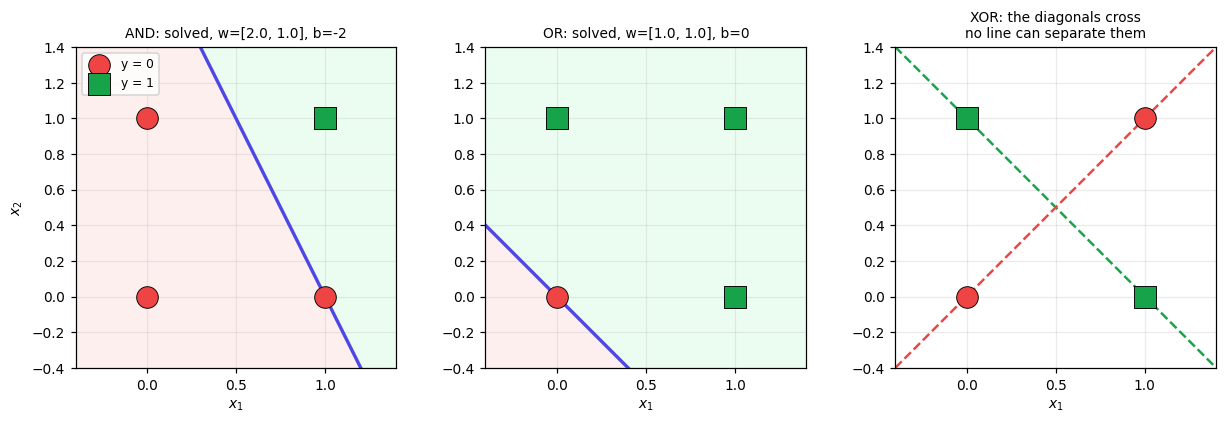

AND and OR each have three points of one class and one of the other -- a
single point can always be cut off with a line. XOR has two of each, placed
so that any line separating one positive from one negative puts the other
positive on the wrong side. Section 2.5 proves it; this is what it looks like.


In [2]:
fig, axes = plt.subplots(1, 3, figsize=(11.5, 3.7))
lines = {"AND": ([2.0, 1.0], -2.0), "OR": ([1.0, 1.0], 0.0), "XOR": None}

for ax, (name, y) in zip(axes, TARGETS.items()):
    pts = np.array(INPUTS)
    lab = np.array(y)
    ax.scatter(pts[lab == 0, 0], pts[lab == 0, 1], s=200, color="#ef4444",
               marker="o", zorder=5, label="y = 0", edgecolor="black", lw=.6)
    ax.scatter(pts[lab == 1, 0], pts[lab == 1, 1], s=200, color="#16a34a",
               marker="s", zorder=5, label="y = 1", edgecolor="black", lw=.6)

    sol = lines[name]
    if sol is not None:
        w, b = sol
        gx = np.linspace(-0.4, 1.4, 50)
        ax.plot(gx, -(w[0] * gx + b) / w[1], color="#4f46e5", lw=2.2)
        XX, YY = np.meshgrid(np.linspace(-.4, 1.4, 200), np.linspace(-.4, 1.4, 200))
        ax.contourf(XX, YY, (w[0] * XX + w[1] * YY + b > 0).astype(float),
                    levels=[-.5, .5, 1.5], colors=["#fee2e2", "#dcfce7"], alpha=.55)
        ax.set_title(f"{name}: solved, w={w}, b={b:g}", fontsize=9)
    else:
        ax.plot([-0.4, 1.4], [1.4, -0.4], color="#16a34a", ls="--", lw=1.6)
        ax.plot([-0.4, 1.4], [-0.4, 1.4], color="#ef4444", ls="--", lw=1.6)
        ax.set_title("XOR: the diagonals cross\nno line can separate them", fontsize=9)

    ax.set_xlim(-.4, 1.4); ax.set_ylim(-.4, 1.4)
    ax.set_xlabel("$x_1$"); ax.set_aspect("equal")
axes[0].set_ylabel("$x_2$")
axes[0].legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

print("""AND and OR each have three points of one class and one of the other -- a
single point can always be cut off with a line. XOR has two of each, placed
so that any line separating one positive from one negative puts the other
positive on the wrong side. Section 2.5 proves it; this is what it looks like.""")

### 4.2 Training, and the failure that never announces itself

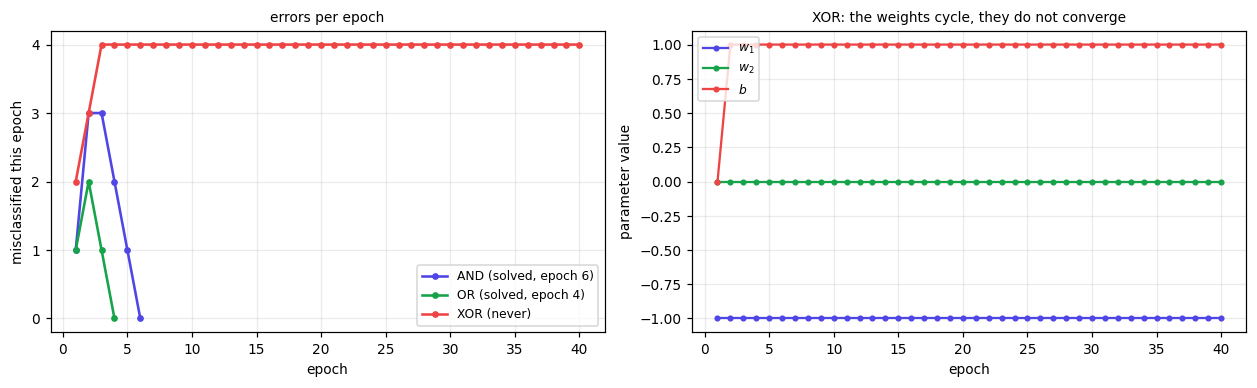

  AND  w = ['2', '1'], b = -2   converged at epoch 6
  OR   w = ['1', '1'], b = 0   converged at epoch 4
  XOR  w = ['-1', '0'], b = 1   NEVER converged (4 errors, still)


In [3]:
def step(z):
    return 1.0 if z > 0 else 0.0


def perceptron_train(inputs, targets, lr=1.0, epochs=40, record=False):
    """Rosenblatt's rule. Returns (w, b, epoch_converged_or_None, history)."""
    w = [0.0, 0.0]
    b = 0.0
    history = []
    for ep in range(1, epochs + 1):
        errors = 0
        for x, y in zip(inputs, targets):
            pred = step(w[0] * x[0] + w[1] * x[1] + b)
            d = y - pred
            if d != 0.0:
                w = [w[0] + lr * d * x[0], w[1] + lr * d * x[1]]
                b = b + lr * d
                errors += 1
        history.append((ep, list(w), b, errors))
        if errors == 0:
            return w, b, ep, history
    return w, b, None, history


results = {}
for name, y in TARGETS.items():
    results[name] = perceptron_train(INPUTS, y)

fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.6))
for name, colour in [("AND", "#4f46e5"), ("OR", "#16a34a"), ("XOR", "#ef4444")]:
    _, _, ep, hist = results[name]
    ax0.plot([h[0] for h in hist], [h[3] for h in hist], "-o", ms=3.4, lw=1.7,
             color=colour, label=f"{name}" + (f" (solved, epoch {ep})" if ep else " (never)"))
ax0.set_xlabel("epoch"); ax0.set_ylabel("misclassified this epoch")
ax0.set_title("errors per epoch", fontsize=9)
ax0.set_yticks([0, 1, 2, 3, 4]); ax0.legend(fontsize=8)

_, _, _, xh = results["XOR"]
ax1.plot([h[0] for h in xh], [h[1][0] for h in xh], "-o", ms=3, label="$w_1$", color="#4f46e5")
ax1.plot([h[0] for h in xh], [h[1][1] for h in xh], "-o", ms=3, label="$w_2$", color="#16a34a")
ax1.plot([h[0] for h in xh], [h[2] for h in xh], "-o", ms=3, label="$b$", color="#ef4444")
ax1.set_xlabel("epoch"); ax1.set_ylabel("parameter value")
ax1.set_title("XOR: the weights cycle, they do not converge", fontsize=9)
ax1.legend(fontsize=8)
plt.tight_layout(); plt.show()

for name in ("AND", "OR", "XOR"):
    w, b, ep, hist = results[name]
    verdict = f"converged at epoch {ep}" if ep else f"NEVER converged ({hist[-1][3]} errors, still)"
    print(f"  {name:<4} w = {[f'{v:g}' for v in w]}, b = {b:g}   {verdict}")

assert results["AND"][2] == TRUTH["and_epochs"]
assert results["OR"][2] == TRUTH["or_epochs"]
assert results["XOR"][2] is TRUTH["xor_epochs"]

### 4.3 Two lines instead of one

The hidden layer computes OR and AND. In those coordinates XOR becomes
linearly separable — the two middle points collapse onto the same hidden
state $(1,0)$, and a single line finishes the job.

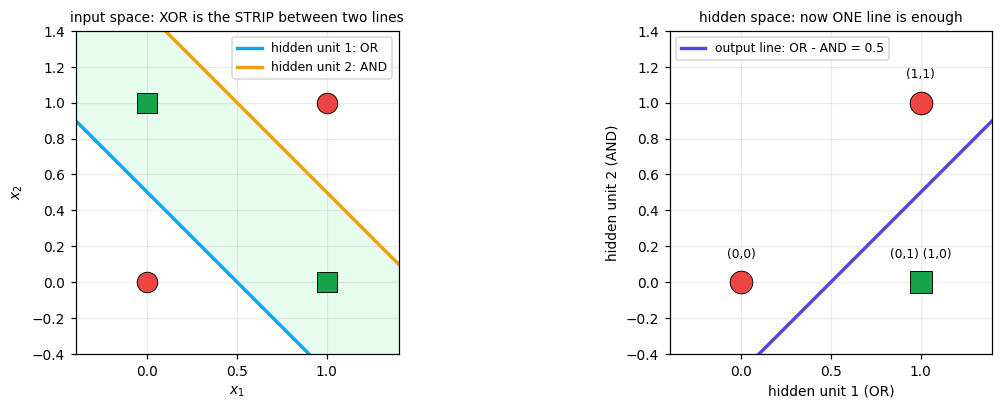

     input   OR   AND   output   target
  (0,0)       0     0        0        0
  (0,1)       1     0        1        1
  (1,0)       1     0        1        1
  (1,1)       1     1        0        0

Look at the right-hand panel. (0,1) and (1,0) have been mapped onto the SAME
hidden state (1,0) -- the hidden layer threw away the distinction between
them, because XOR does not care which input was the 1. Having discarded the
irrelevant information, what remains is linearly separable.

That is what a hidden layer does. Not "more capacity" -- a change of
coordinates in which the question becomes answerable.


In [4]:
def h_or(x1, x2):
    return step(x1 + x2 - 0.5)


def h_and(x1, x2):
    return step(x1 + x2 - 1.5)


def xor_net(x1, x2):
    return step(h_or(x1, x2) - h_and(x1, x2) - 0.5)


fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(11.5, 3.8))

pts = np.array(INPUTS); lab = np.array(TARGETS["XOR"])
gx = np.linspace(-0.4, 1.4, 50)
ax0.plot(gx, 0.5 - gx, color="#0ea5e9", lw=2.2, label="hidden unit 1: OR")
ax0.plot(gx, 1.5 - gx, color="#f59e0b", lw=2.2, label="hidden unit 2: AND")
ax0.fill_between(gx, 0.5 - gx, 1.5 - gx, color="#dcfce7", alpha=.7)
ax0.scatter(pts[lab == 0, 0], pts[lab == 0, 1], s=180, color="#ef4444",
            zorder=5, edgecolor="black", lw=.6)
ax0.scatter(pts[lab == 1, 0], pts[lab == 1, 1], s=180, color="#16a34a",
            marker="s", zorder=5, edgecolor="black", lw=.6)
ax0.set_xlim(-.4, 1.4); ax0.set_ylim(-.4, 1.4); ax0.set_aspect("equal")
ax0.set_xlabel("$x_1$"); ax0.set_ylabel("$x_2$")
ax0.set_title("input space: XOR is the STRIP between two lines", fontsize=9)
ax0.legend(fontsize=8, loc="upper right")

seen = {}
for (x1, x2), y in zip(INPUTS, TARGETS["XOR"]):
    hs = (h_or(x1, x2), h_and(x1, x2))
    seen.setdefault(hs, []).append((f"({x1:.0f},{x2:.0f})", y))
for (a, b_), items in seen.items():
    y = items[0][1]
    ax1.scatter([a], [b_], s=220, color="#16a34a" if y else "#ef4444",
                marker="s" if y else "o", zorder=5, edgecolor="black", lw=.6)
    ax1.annotate(" ".join(i[0] for i in items), (a, b_), textcoords="offset points",
                 xytext=(0, 16), ha="center", fontsize=8)
gh = np.linspace(-0.4, 1.4, 50)
ax1.plot(gh, gh - 0.5, color="#4f46e5", lw=2.2, label="output line: OR - AND = 0.5")
ax1.set_xlim(-.4, 1.4); ax1.set_ylim(-.4, 1.4); ax1.set_aspect("equal")
ax1.set_xlabel("hidden unit 1 (OR)"); ax1.set_ylabel("hidden unit 2 (AND)")
ax1.set_title("hidden space: now ONE line is enough", fontsize=9)
ax1.legend(fontsize=8, loc="upper left")
plt.tight_layout(); plt.show()

print(f"  {'input':>8} {'OR':>4} {'AND':>5} {'output':>8} {'target':>8}")
for (x1, x2), t in zip(INPUTS, TARGETS["XOR"]):
    print(f"  ({x1:.0f},{x2:.0f})    {h_or(x1,x2):>4.0f} {h_and(x1,x2):>5.0f} "
          f"{xor_net(x1,x2):>8.0f} {t:>8.0f}")
    assert xor_net(x1, x2) == t

print("""
Look at the right-hand panel. (0,1) and (1,0) have been mapped onto the SAME
hidden state (1,0) -- the hidden layer threw away the distinction between
them, because XOR does not care which input was the 1. Having discarded the
irrelevant information, what remains is linearly separable.

That is what a hidden layer does. Not "more capacity" -- a change of
coordinates in which the question becomes answerable.""")

## 5. Scratch code — pure Python, no imports

`perceptron_train` above already is the pure-Python implementation: no
imports, no arrays, no calculus. Here we check it against the hand trace in
section 3, epoch by epoch.

In [5]:
_, _, _, and_hist = perceptron_train(INPUTS, TARGETS["AND"], record=True)

print(f"  {'epoch':>6} {'w':>14} {'b':>6} {'errors':>8}")
for ep, w, b, errs in and_hist:
    print(f"  {ep:>6} {str([f'{v:g}' for v in w]):>14} {b:>6g} {errs:>8}")

scratch = {
    "epoch1_w": and_hist[0][1], "epoch1_b": and_hist[0][2], "epoch1_errors": and_hist[0][3],
    "epoch2_w": and_hist[1][1], "epoch2_b": and_hist[1][2], "epoch2_errors": and_hist[1][3],
    "and_w": results["AND"][0], "and_b": results["AND"][1], "and_epochs": results["AND"][2],
    "or_w": results["OR"][0], "or_b": results["OR"][1], "or_epochs": results["OR"][2],
    "xor_epochs": results["XOR"][2],
    "xor_errors_per_epoch": results["XOR"][3][-1][3],
}
for k, v in scratch.items():
    ok = "OK " if v == TRUTH[k] else "XX "
    print(f"  {ok} {k:<22} {str(v):>16}   hand {str(TRUTH[k])}")
assert scratch == TRUTH, "the scratch run disagrees with the hand trace"
print("\nEvery epoch matches the table in section 3, including epoch 2 getting WORSE.")

   epoch              w      b   errors
       1     ['1', '1']      1        1
       2     ['2', '1']      0        3
       3     ['2', '1']     -1        3
       4     ['2', '2']     -1        2
       5     ['2', '1']     -2        1
       6     ['2', '1']     -2        0
  OK  epoch1_w                     [1.0, 1.0]   hand [1.0, 1.0]
  OK  epoch1_b                            1.0   hand 1.0
  OK  epoch1_errors                         1   hand 1
  OK  epoch2_w                     [2.0, 1.0]   hand [2.0, 1.0]
  OK  epoch2_b                            0.0   hand 0.0
  OK  epoch2_errors                         3   hand 3
  OK  and_w                        [2.0, 1.0]   hand [2.0, 1.0]
  OK  and_b                              -2.0   hand -2.0
  OK  and_epochs                            6   hand 6
  OK  or_w                         [1.0, 1.0]   hand [1.0, 1.0]
  OK  or_b                                0.0   hand 0.0
  OK  or_epochs                             4   hand 4
  OK  xor_epoch

### 5.1 Why we cannot just use gradient descent here

The claim in section 2.3 was that the step function kills every gradient.
Here it is, measured.

In [6]:
def numeric_derivative(f, z, eps=1e-5):
    return (f(z + eps) - f(z - eps)) / (2 * eps)


print("  numerical derivative of step(z):")
for z in (-2.0, -0.5, 0.5, 2.0, 0.0):
    d = numeric_derivative(step, z)
    note = "   <- undefined at the jump; the difference quotient explodes" if z == 0.0 else ""
    print(f"    z = {z:>5}:  {d:>12.1f}{note}")

print("""
Zero everywhere except one point, where it is infinite. There is no useful
gradient signal anywhere: a chain rule through this layer multiplies by 0 and
annihilates everything behind it.

This is the single technical reason the field needed the sigmoid. Rosenblatt's
rule works for ONE layer -- but it has no way to tell a HIDDEN unit what it
should have done, because "the error" is only defined at the output. Getting
blame back to a hidden layer needs the chain rule, and the chain rule needs a
non-zero derivative. Lesson 12 replaces the step with smooth alternatives and
Lesson 11 does the blame assignment.""")

  numerical derivative of step(z):
    z =  -2.0:           0.0
    z =  -0.5:           0.0
    z =   0.5:           0.0
    z =   2.0:           0.0
    z =   0.0:       50000.0   <- undefined at the jump; the difference quotient explodes

Zero everywhere except one point, where it is infinite. There is no useful
gradient signal anywhere: a chain rule through this layer multiplies by 0 and
annihilates everything behind it.

This is the single technical reason the field needed the sigmoid. Rosenblatt's
rule works for ONE layer -- but it has no way to tell a HIDDEN unit what it
should have done, because "the error" is only defined at the output. Getting
blame back to a hidden layer needs the chain rule, and the chain rule needs a
non-zero derivative. Lesson 12 replaces the step with smooth alternatives and
Lesson 11 does the blame assignment.


## 6. NumPy — vectorized

The whole training loop, with the per-sample Python loop replaced by array
operations. Note this is the **batch** variant: it computes all predictions
first, then applies all updates — which is a genuinely different algorithm
from the sequential rule, as section 9.2 shows.

In [7]:
X = np.array(INPUTS)
np_results = {}

for name, y in TARGETS.items():
    y = np.array(y)
    w = np.zeros(2)
    b = 0.0
    converged = None
    for ep in range(1, 41):
        pred = (X @ w + b > 0).astype(float)
        err = y - pred
        n_wrong = int(np.count_nonzero(err))
        if n_wrong == 0:
            converged = ep - 1 if ep > 1 else 0
            break
        w = w + X.T @ err          # sum of eta * (y - yhat) * x over the batch
        b = b + err.sum()
    np_results[name] = (w, b, converged)
    acc = float(np.mean((X @ w + b > 0).astype(float) == y))
    print(f"  {name:<4} w = {np.round(w, 3)}, b = {b:g}   accuracy {acc:.2f}"
          + ("" if acc == 1.0 else "   <- cannot do better"))

assert float(np.mean((X @ np_results["XOR"][0] + np_results["XOR"][1] > 0).astype(float)
                     == np.array(TARGETS["XOR"]))) < 1.0

  AND  w = [1. 1.], b = -1   accuracy 1.00
  OR   w = [2. 2.], b = 0   accuracy 1.00
  XOR  w = [0. 0.], b = 0   accuracy 0.50   <- cannot do better


In [8]:
# The hand-placed XOR network, vectorized. Two hidden units in one matrix.
W1 = np.array([[1.0, 1.0],       # hidden unit 1 weights (OR)
               [1.0, 1.0]]).T    # hidden unit 2 weights (AND)
b1 = np.array([-0.5, -1.5])
W2 = np.array([1.0, -1.0])       # output: OR minus AND
b2 = -0.5

H = (X @ W1 + b1 > 0).astype(float)
out = (H @ W2 + b2 > 0).astype(float)

print(f"  hidden layer H (shape {H.shape}):\n{H}")
print(f"  output        : {out}")
print(f"  XOR target    : {np.array(TARGETS['XOR'])}")
assert np.array_equal(out, np.array(TARGETS["XOR"]))
print("\n  Two lines, one composition, problem solved. This is an MLP -- Lesson 10.")

  hidden layer H (shape (4, 2)):
[[0. 0.]
 [1. 0.]
 [1. 0.]
 [1. 1.]]
  output        : [0. 1. 1. 0.]
  XOR target    : [0. 1. 1. 0.]

  Two lines, one composition, problem solved. This is an MLP -- Lesson 10.


## 7. TensorFlow

A single Dense unit cannot learn XOR no matter how long it trains — that is
the impossibility proof, not a tuning failure. Add two hidden units and it
learns it easily. We run both.

In [9]:
try:
    import tensorflow as tf
    HAS_TF = True
    tf.random.set_seed(0)
    print(f"TensorFlow {tf.__version__}")
except ImportError:
    HAS_TF = False
    print("TensorFlow not installed locally -- section skipped. It runs on Kaggle.")

TensorFlow not installed locally -- section skipped. It runs on Kaggle.


In [10]:
if HAS_TF:
    Xt = np.array(INPUTS, dtype="float32")
    tf_res = {}

    for name, y in TARGETS.items():
        yt = np.array(y, dtype="float32")
        tf.random.set_seed(0)
        flat = tf.keras.Sequential([
            tf.keras.layers.Dense(1, activation="sigmoid", input_shape=(2,))
        ])
        flat.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss="binary_crossentropy")
        flat.fit(Xt, yt, epochs=3000, verbose=0)
        acc = float(np.mean((flat.predict(Xt, verbose=0).ravel() >= .5) == yt))
        tf_res[name] = acc
        print(f"  single layer on {name:<4}: accuracy {acc:.2f}"
              + ("" if acc == 1.0 else "   <- 3000 epochs of Adam cannot fix a proof"))

    assert tf_res["AND"] == 1.0 and tf_res["OR"] == 1.0
    assert tf_res["XOR"] < 1.0, "a single layer must fail XOR"

In [11]:
if HAS_TF:
    tf.random.set_seed(0)
    deep = tf.keras.Sequential([
        tf.keras.layers.Dense(2, activation="tanh", input_shape=(2,)),
        tf.keras.layers.Dense(1, activation="sigmoid"),
    ])
    deep.compile(optimizer=tf.keras.optimizers.Adam(0.1), loss="binary_crossentropy")
    deep.fit(Xt, np.array(TARGETS["XOR"], dtype="float32"), epochs=2000, verbose=0)
    p = deep.predict(Xt, verbose=0).ravel()
    acc_deep = float(np.mean((p >= .5) == np.array(TARGETS["XOR"])))
    print(f"  TWO hidden units on XOR: accuracy {acc_deep:.2f}")
    print(f"  predictions: {np.round(p, 4)}   target: {TARGETS['XOR']}")
    assert acc_deep == 1.0
    print("\n  Two extra parameters turn an impossible problem into an easy one.")

## 8. Agreement check

In [12]:
implementations = {"hand (section 3)": TRUTH, "scratch": scratch}

print(f"{'quantity':<24} " + " ".join(f"{n:>20}" for n in implementations))
print("-" * (25 + 21 * len(implementations)))
for k in TRUTH:
    print(f"{k:<24} " + " ".join(f"{str(impl[k]):>20}" for impl in implementations.values()))

for name, impl in implementations.items():
    for k in TRUTH:
        assert impl[k] == TRUTH[k], f"{name} disagrees on {k}"

# the NumPy and hand-built networks must agree on the XOR solution
assert np.array_equal(out, np.array(TARGETS["XOR"]))
assert all(xor_net(x1, x2) == t for (x1, x2), t in zip(INPUTS, TARGETS["XOR"]))
print("\nScratch matches the hand trace; the pure-Python and NumPy XOR networks"
      "\nboth reproduce XOR exactly.")

quantity                     hand (section 3)              scratch
-------------------------------------------------------------------
epoch1_w                           [1.0, 1.0]           [1.0, 1.0]
epoch1_b                                  1.0                  1.0
epoch1_errors                               1                    1
epoch2_w                           [2.0, 1.0]           [2.0, 1.0]
epoch2_b                                  0.0                  0.0
epoch2_errors                               3                    3
and_w                              [2.0, 1.0]           [2.0, 1.0]
and_b                                    -2.0                 -2.0
and_epochs                                  6                    6
or_w                               [1.0, 1.0]           [1.0, 1.0]
or_b                                      0.0                  0.0
or_epochs                                   4                    4
xor_epochs                               None                

## 9. The silent failures

### 9.1 Non-convergence that looks exactly like convergence

The perceptron returns weights whether or not it succeeded. Nothing raises.

In [13]:
w, b, ep, hist = perceptron_train(INPUTS, TARGETS["XOR"], epochs=100_000)
acc = sum(step(w[0] * x[0] + w[1] * x[1] + b) == y
          for x, y in zip(INPUTS, TARGETS["XOR"])) / 4

print(f"  after 100,000 epochs on XOR:")
print(f"    returned w = {[f'{v:g}' for v in w]}, b = {b:g}")
print(f"    accuracy   = {acc:.2f}")
print(f"    converged  = {ep}")

states = {(tuple(h[1]), h[2]) for h in hist}
print(f"    distinct (w, b) states visited in 100,000 epochs: {len(states)}")
print(f"    they are: {sorted(states)}")

print("""
It cycles through a handful of states forever. The returned weights are not
a "best effort" -- they are simply wherever the loop happened to stop.

Two habits this should install for good:
  1. ALWAYS return and check a convergence flag. `perceptron_train` returns
     None for the epoch when it failed; a version that returned only (w, b)
     would be actively dangerous.
  2. A fixed epoch budget with no convergence test is a bug, not a
     configuration. Modern training hides this behind "we ran 100 epochs" --
     the question is always whether that was enough.""")

  after 100,000 epochs on XOR:
    returned w = ['-1', '0'], b = 1
    accuracy   = 0.50
    converged  = None
    distinct (w, b) states visited in 100,000 epochs: 2
    they are: [((-1.0, 0.0), 0.0), ((-1.0, 0.0), 1.0)]

It cycles through a handful of states forever. The returned weights are not
a "best effort" -- they are simply wherever the loop happened to stop.

Two habits this should install for good:
  1. ALWAYS return and check a convergence flag. `perceptron_train` returns
     None for the epoch when it failed; a version that returned only (w, b)
     would be actively dangerous.
  2. A fixed epoch budget with no convergence test is a bug, not a
     configuration. Modern training hides this behind "we ran 100 epochs" --
     the question is always whether that was enough.


### 9.2 Batch updates are a different algorithm

Section 6 summed the updates over the whole batch instead of applying them
one at a time. That is not an optimisation; it can change the answer.

In [14]:
def perceptron_batch(inputs, targets, lr=1.0, epochs=40):
    X_ = np.array(inputs); y_ = np.array(targets)
    w = np.zeros(2); b = 0.0
    for ep in range(1, epochs + 1):
        pred = (X_ @ w + b > 0).astype(float)
        err = y_ - pred
        if not np.count_nonzero(err):
            return w, b, ep
        w = w + lr * X_.T @ err
        b = b + lr * err.sum()
    return w, b, None


print(f"  {'problem':<6} {'sequential':>22} {'batch':>22}")
for name, y in TARGETS.items():
    ws, bs, es, _ = perceptron_train(INPUTS, y)
    wb, bb, eb = perceptron_batch(INPUTS, y)
    s = f"ep {es}" if es else "never"
    b_ = f"ep {eb}" if eb else "never"
    print(f"  {name:<6} {str([f'{v:g}' for v in ws]) + ' ' + s:>22} "
          f"{str([f'{v:g}' for v in wb]) + ' ' + b_:>22}")

print("""
Same rule, same data, same learning rate, different answers and different
epoch counts. The sequential version uses each update immediately, so later
samples in the epoch see already-corrected weights; the batch version does
not. Rosenblatt's convergence theorem is proved for the SEQUENTIAL rule --
the batch variant has no such guarantee.

The same distinction returns in Lesson 21 as stochastic versus batch gradient
descent, where it stops being a curiosity and starts being the reason SGD
generalises better.""")

  problem             sequential                  batch
  AND           ['2', '1'] ep 6        ['1', '1'] ep 4
  OR            ['1', '1'] ep 4        ['2', '2'] ep 5
  XOR         ['-1', '0'] never       ['0', '0'] never

Same rule, same data, same learning rate, different answers and different
epoch counts. The sequential version uses each update immediately, so later
samples in the epoch see already-corrected weights; the batch version does
not. Rosenblatt's convergence theorem is proved for the SEQUENTIAL rule --
the batch variant has no such guarantee.

The same distinction returns in Lesson 21 as stochastic versus batch gradient
descent, where it stops being a curiosity and starts being the reason SGD
generalises better.


## 10. Exercises

Solutions: `solutions/09-the-perceptron-solutions.ipynb`.

In [15]:
# --- Exercise 1 -------------------------------------------------------
# Hand-trace epoch 3 of AND, starting from w = [2,1], b = 0 (the end of
# epoch 2). Give the weights, bias and error count at the end of epoch 3.
ex1_w = None            # [w1, w2]
ex1_b = None
ex1_errors = None

_, _, _, _h = perceptron_train(INPUTS, TARGETS["AND"])
_e3 = _h[2]
assert ex1_w is not None and [float(v) for v in ex1_w] == _e3[1], f"w should be {_e3[1]}"
assert ex1_b is not None and float(ex1_b) == _e3[2], f"b should be {_e3[2]}"
assert ex1_errors == _e3[3], f"errors should be {_e3[3]}"
print(f"Ex 1 OK -- epoch 3 ends at w={_e3[1]}, b={_e3[2]:g}, {_e3[3]} errors")

AssertionError: w should be [2.0, 1.0]

In [16]:
# --- Exercise 2 -------------------------------------------------------
# Which of the 16 possible boolean functions of 2 inputs are NOT linearly
# separable? Return the count. (Hint: the answer is small, and XOR is one.)
ex2_count = None

def _separable(bits):
    _, _, ep, _ = perceptron_train(INPUTS, list(map(float, bits)), epochs=200)
    return ep is not None
_not_sep = [b for b in itertools.product([0, 1], repeat=4) if not _separable(b)]
assert ex2_count == len(_not_sep), f"there are {len(_not_sep)}"
print(f"Ex 2 OK -- {len(_not_sep)} of 16: {_not_sep}")
print("         XOR and its negation XNOR. Every other boolean function of two")
print("         inputs IS linearly separable -- the wall is narrow but absolute.")

AssertionError: there are 2

In [17]:
# --- Exercise 3 -------------------------------------------------------
# Build NAND by hand: weights and bias giving 0 only for (1,1).
ex3_w = None            # [w1, w2]
ex3_b = None

assert ex3_w is not None and ex3_b is not None
for _x, _t in zip(INPUTS, [1.0, 1.0, 1.0, 0.0]):
    _got = step(ex3_w[0] * _x[0] + ex3_w[1] * _x[1] + ex3_b)
    assert _got == _t, f"NAND({_x}) gave {_got}, expected {_t}"
print("Ex 3 OK -- NAND is linearly separable, and it is functionally complete:")
print("         every boolean function can be built from NAND gates alone.")

AssertionError: 

In [18]:
# --- Exercise 4 -------------------------------------------------------
# Implement XOR using only NAND perceptrons (no OR/AND shortcuts).
#     XOR(a,b) = NAND(NAND(a, NAND(a,b)), NAND(b, NAND(a,b)))
def nand(a, b):
    return None     # <-- one perceptron

def xor_from_nand(a, b):
    return None     # <-- compose four of them


for _x, _t in zip(INPUTS, TARGETS["XOR"]):
    _got = xor_from_nand(_x[0], _x[1])
    assert _got is not None and _got == _t, f"XOR{_x} gave {_got}, expected {_t}"
print("Ex 4 OK -- four NAND units, arranged in two layers, compute XOR.")
print("         Depth, not width, is what bought you the extra expressiveness.")

AssertionError: XOR(0.0, 0.0) gave None, expected 0.0

In [19]:
# --- Exercise 5 -------------------------------------------------------
# Show the convergence theorem's bound in action. For a separable 2-D dataset,
# count the total number of WEIGHT UPDATES (not epochs) the perceptron makes.
def count_updates(inputs, targets, lr=1.0, epochs=200):
    return None     # <-- total updates, or None if it never converges


assert count_updates(INPUTS, TARGETS["AND"]) is not None
assert count_updates(INPUTS, TARGETS["XOR"], epochs=50) is None, "XOR never converges"
_u = count_updates(INPUTS, TARGETS["AND"])
print(f"Ex 5 OK -- AND needed {_u} updates. The theorem bounds this by (R/gamma)^2,")
print("         which depends only on the data's geometry, never on the learning rate.")

AssertionError: 

In [20]:
# --- Exercise 6 (stretch) ---------------------------------------------
# The perceptron cannot do XOR, but a FEATURE MAP can rescue it without any
# hidden layer. Add the product x1*x2 as a third input feature and train a
# plain perceptron on the 3-D data. Return (w, b, converged_epoch).
def xor_with_product_feature(epochs=200):
    return None     # <-- (w of length 3, b, epoch)


_r = xor_with_product_feature()
assert _r is not None and len(_r) == 3, "return (w, b, epoch)"
assert _r[2] is not None, "with the product feature it MUST converge"
_w, _b = np.asarray(_r[0], dtype=float), float(_r[1])
for _x, _t in zip(INPUTS, TARGETS["XOR"]):
    _f = np.array([_x[0], _x[1], _x[0] * _x[1]])
    assert step(float(_w @ _f) + _b) == _t
print(f"Ex 6 OK -- converged at epoch {_r[2]} with w={np.round(_w,3)}, b={_b:g}")
print("         Hand-designed features and learned hidden layers do the same job.")
print("         The century's lesson was that LEARNING the features scales better.")

AssertionError: return (w, b, epoch)

## 11. What you learned

- **The perceptron rule needs no calculus.** $\mathbf{w} \mathrel{+}= \eta(y-\hat{y})\mathbf{x}$
  does nothing when correct, and otherwise moves that sample's logit the
  right way by $\eta(\lVert x\rVert^2+1)$ — guaranteed.
- **It is not gradient descent, and could not be.** The step function's
  derivative is zero everywhere and undefined at the jump. Lesson 08's
  sigmoid is a *differentiable step*, and that substitution is what made
  backpropagation possible.
- **Convergence is guaranteed only for separable data.** On XOR the weights
  cycle through a handful of states forever, returning confident-looking
  numbers with no error and no warning. Always return and check a
  convergence flag.
- **XOR is impossible for one layer — proved, not observed.** Adding the
  constraints from rows $(0,1)$ and $(1,0)$ and combining with $(1,1)$ forces
  $b > 0$, contradicting row $(0,0)$. Geometrically: the diagonals of a
  square cross, and one line cannot separate them.
- **Only 2 of the 16 boolean functions of two inputs are unreachable** — XOR
  and XNOR. The wall is narrow, and absolutely solid.
- **A hidden layer is a change of coordinates.** Mapping to (OR, AND) sends
  $(0,1)$ and $(1,0)$ to the *same* point, discarding exactly the
  distinction XOR does not care about — and what remains is separable.
- **Sequential and batch updates are different algorithms**, with different
  answers and only the sequential one covered by the theorem. That
  distinction returns as SGD versus batch GD in Lesson 21.

### Next

**Lesson 10 — The MLP Forward Pass.** We stop placing hidden weights by hand
and build the general multi-layer network: matrices, layers, and a full
trace of one input to one output. We also lose convexity for good — from
Lesson 10 onward the loss surface has hills, valleys and saddle points, and
nothing guarantees you find the bottom.